In [1]:
from utility import load_test_results, architecture_stats, sample_image, plot_image, load_all_my_images

from NeuralNetwork import NeuralNetwork, torch

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.min_rows', 5000)
pd.set_option('display.max_rows', 5000)

In [2]:
classifiers_dict, all_results = load_test_results("Classifier_3")

In [3]:
classifiers_dict

{0: "Classifier_3 (n_neurons_molt_factor=2, do_dropout=['Conv2'])",
 1: "Classifier_3 (n_neurons_molt_factor=2, do_dropout=['Conv3', 'FC1'])",
 2: "Classifier_3 (n_neurons_molt_factor=1, do_dropout=['Conv2', 'Conv3', 'FC1'])",
 3: 'Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=[])',
 4: "Classifier_3 (n_neurons_molt_factor=1, do_dropout=['Conv3'])",
 5: 'Classifier_3 (n_neurons_molt_factor=1, do_dropout=[])',
 6: "Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=['FC1'])",
 7: "Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=['Conv2', 'Conv3'])",
 8: "Classifier_3 (n_neurons_molt_factor=2, do_dropout=['FC1'])",
 9: 'Classifier_3 (n_neurons_molt_factor=2, do_dropout=[])',
 10: "Classifier_3 (n_neurons_molt_factor=1, do_dropout=['Conv2'])",
 11: "Classifier_3 (n_neurons_molt_factor=1, do_dropout=['FC1'])",
 12: "Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=['Conv3'])",
 13: "Classifier_3 (n_neurons_molt_factor=2, do_dropout=['Conv3'])",
 14: "Classifier_3 (n_neurons_m

In [4]:
all_results.head(10)

,test_id,architecture_id,n_neurons_molt_factor,do_dropout,lr,batch_size,patience,data_augmentation_perc,test_accuracies,test_times,train_times
0,0,0,2.0,['Conv2'],0.0005,32,5,0.00,0.020078,0.078545,79.387270
1,1,0,2.0,['Conv2'],0.0005,32,5,0.25,0.020078,0.078202,94.809957
2,2,0,2.0,['Conv2'],0.0005,32,5,0.50,0.020078,0.078102,11.220702
3,3,0,2.0,['Conv2'],0.0005,32,5,0.75,0.020078,0.078387,18.240954
4,4,0,2.0,['Conv2'],0.0005,32,10,0.00,0.020078,0.077921,0.767154
5,5,0,2.0,['Conv2'],0.0005,32,10,0.25,0.020078,0.077911,0.947382
6,6,0,2.0,['Conv2'],0.0005,32,10,0.50,0.020078,0.078122,1.121235
7,7,0,2.0,['Conv2'],0.0005,32,10,0.75,0.020078,0.078348,1.298127
8,8,0,2.0,['Conv2'],0.0005,32,15,0.00,0.020078,0.078156,18.438186
9,9,0,2.0,['Conv2'],0.0005,32,15,0.25,0.020078,0.078327,0.957254


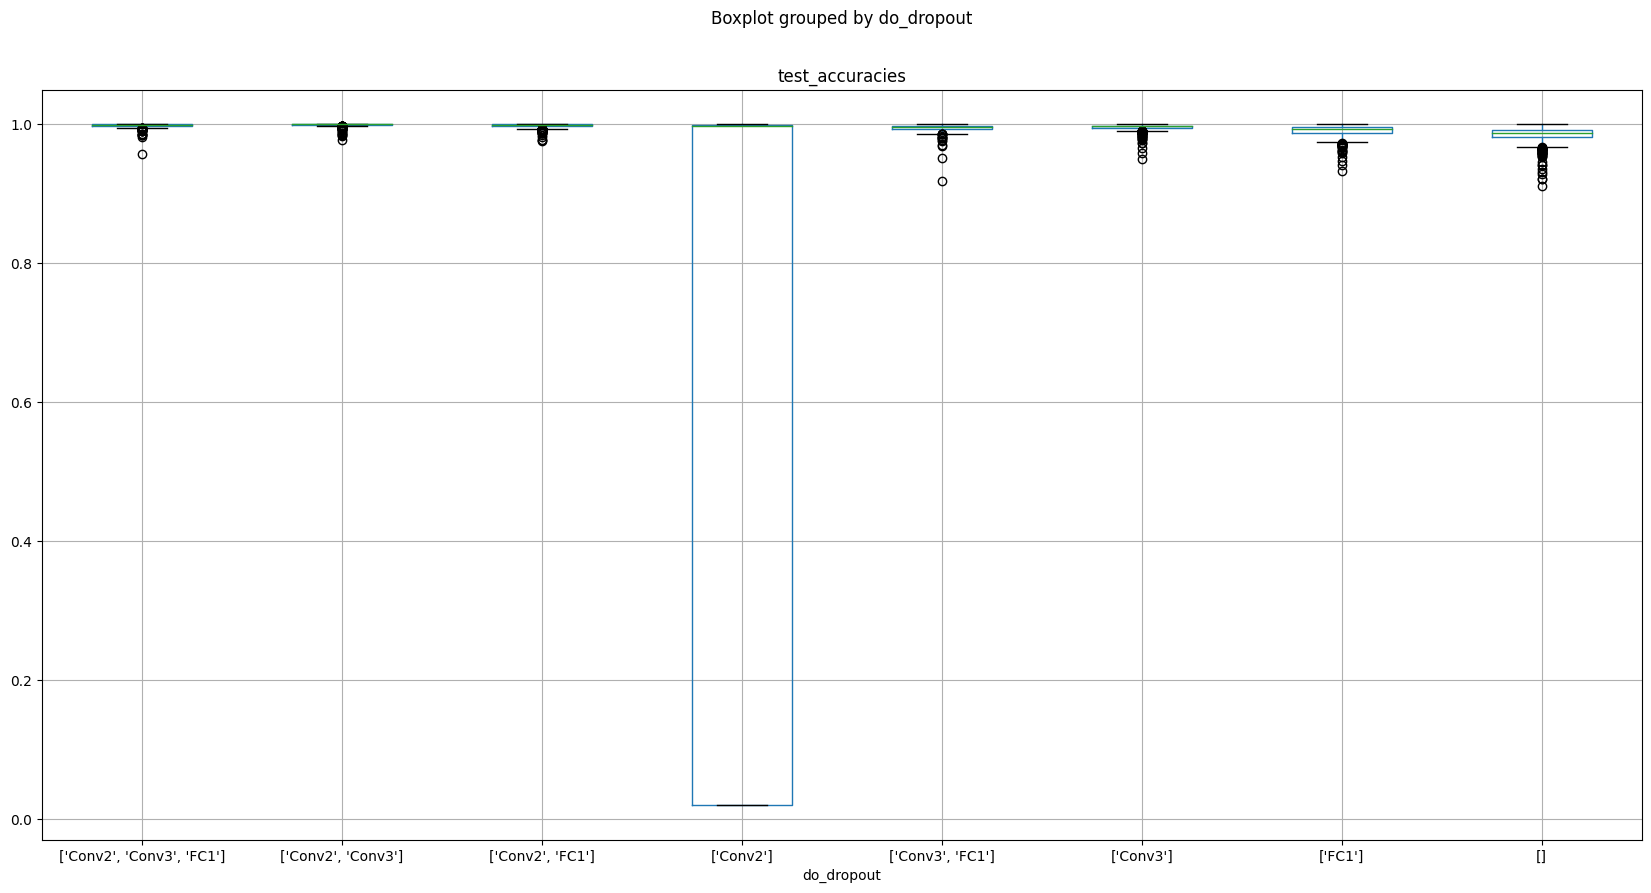

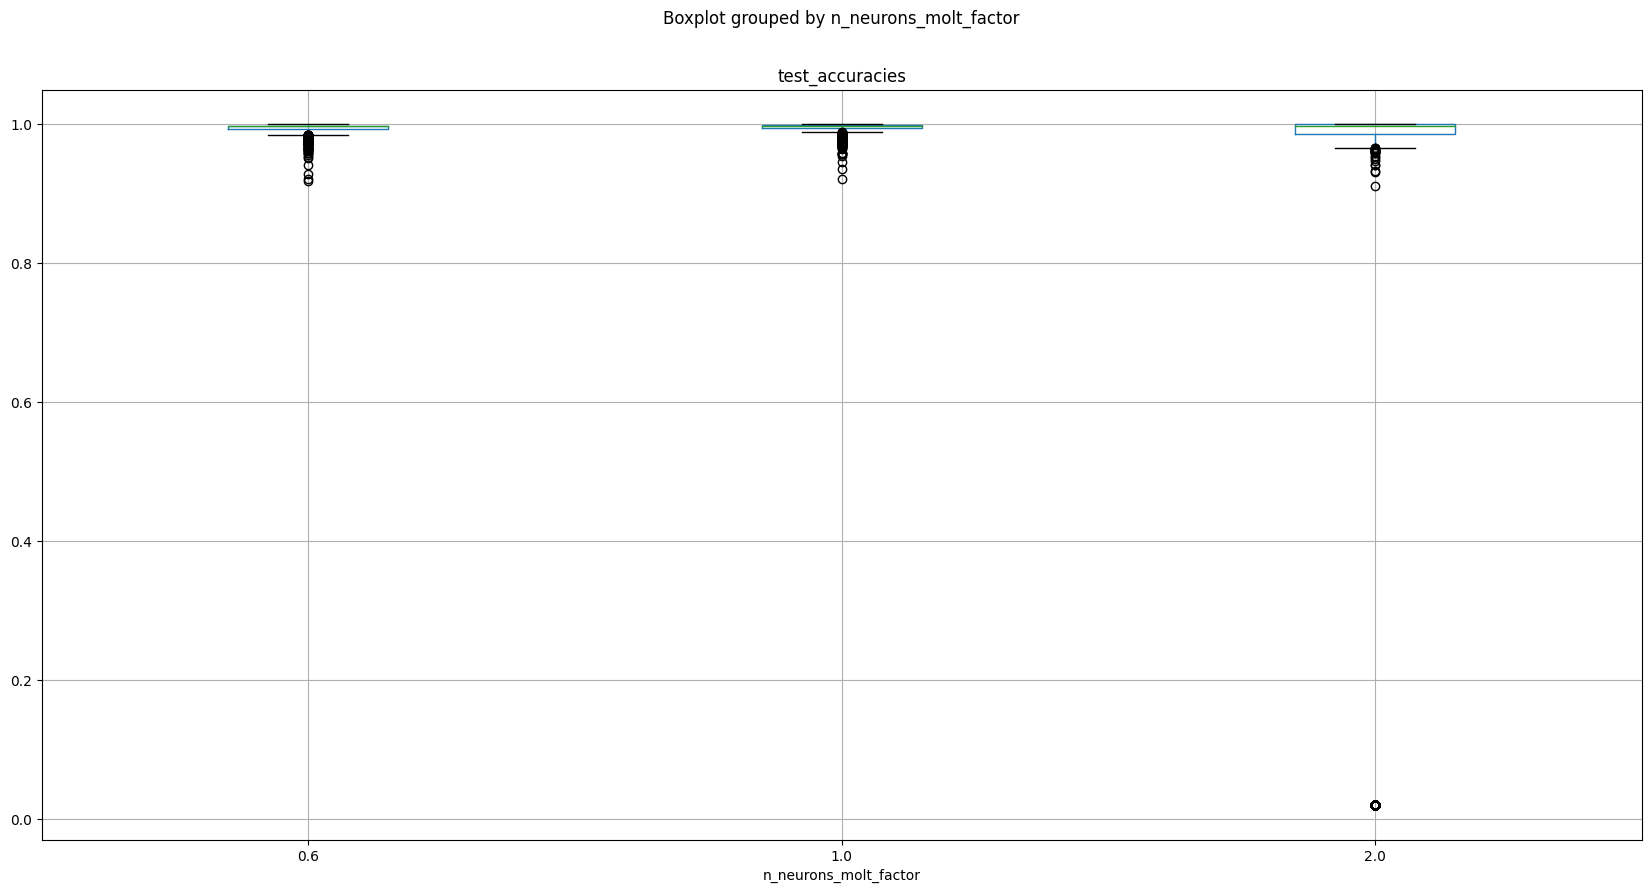

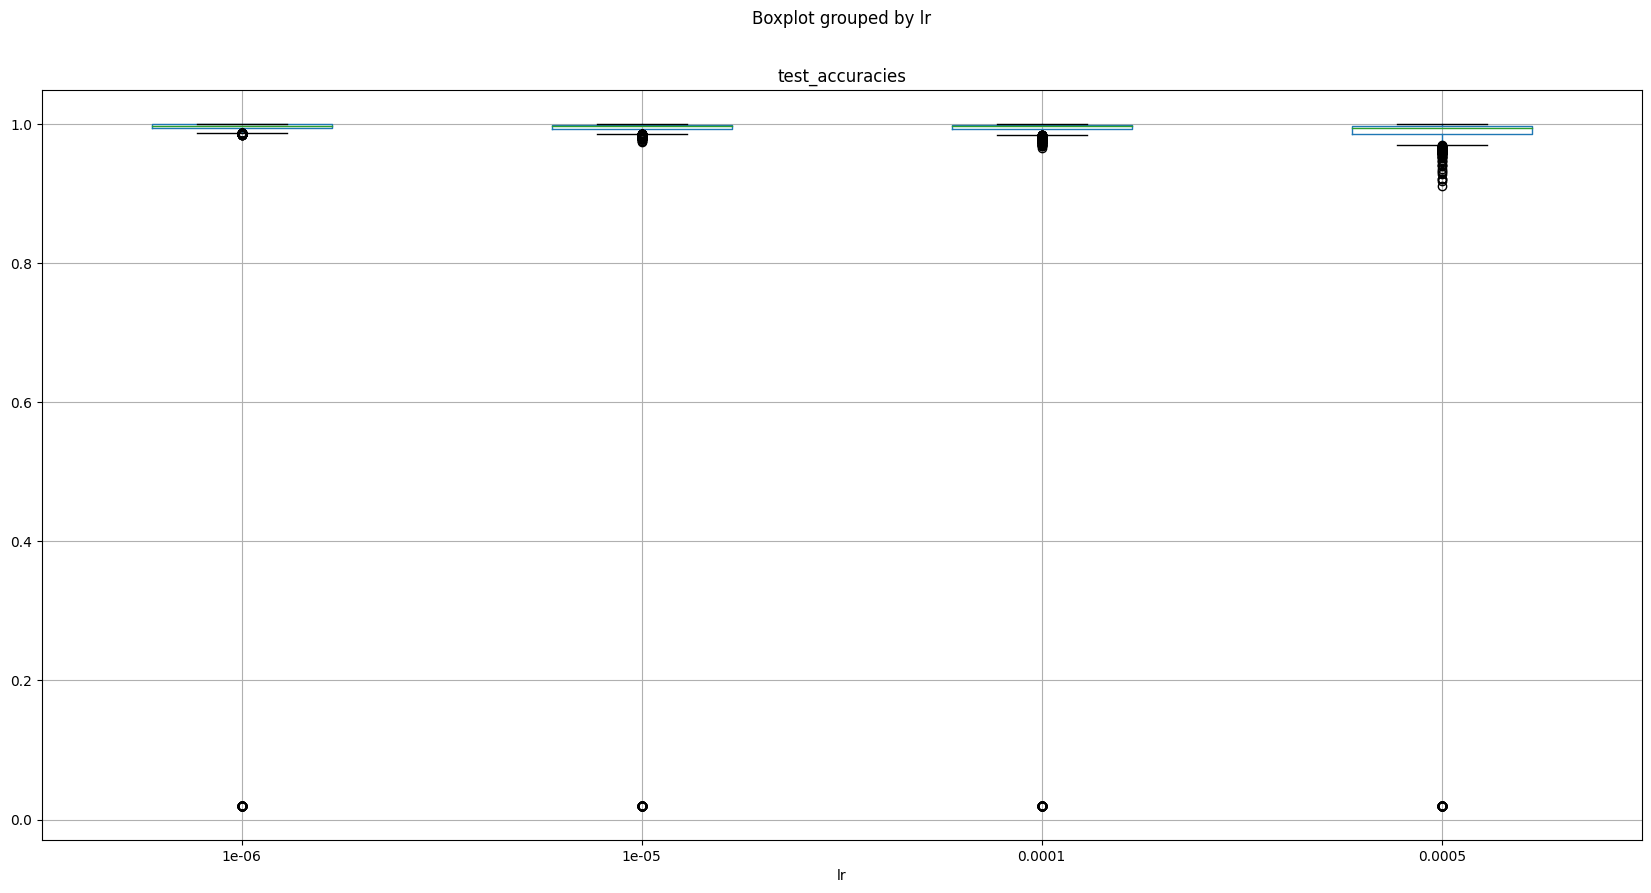

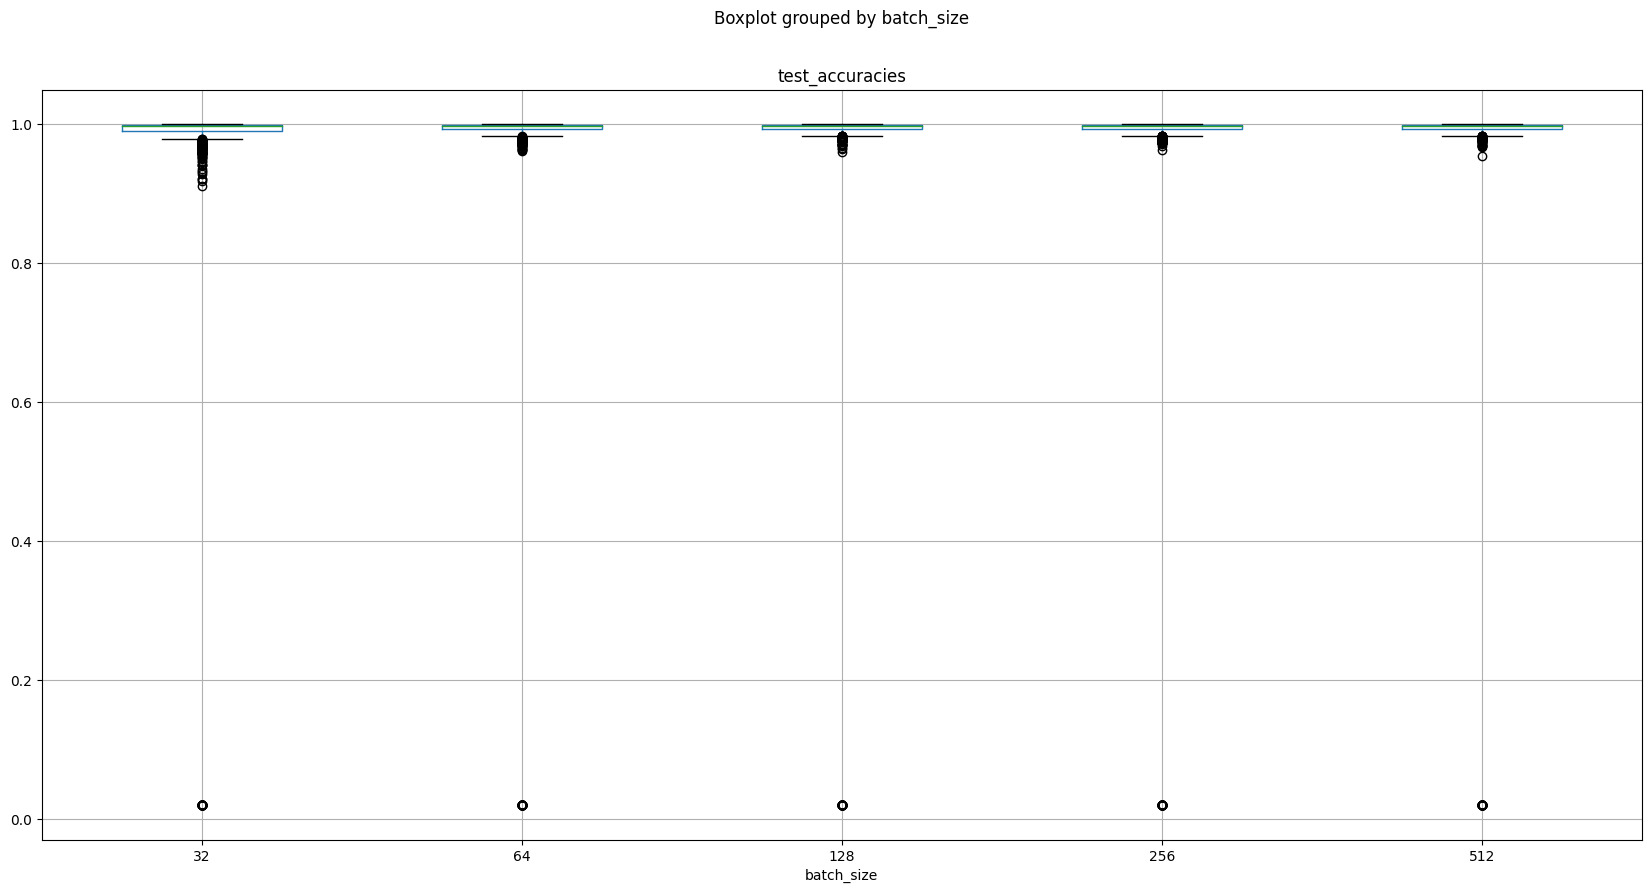

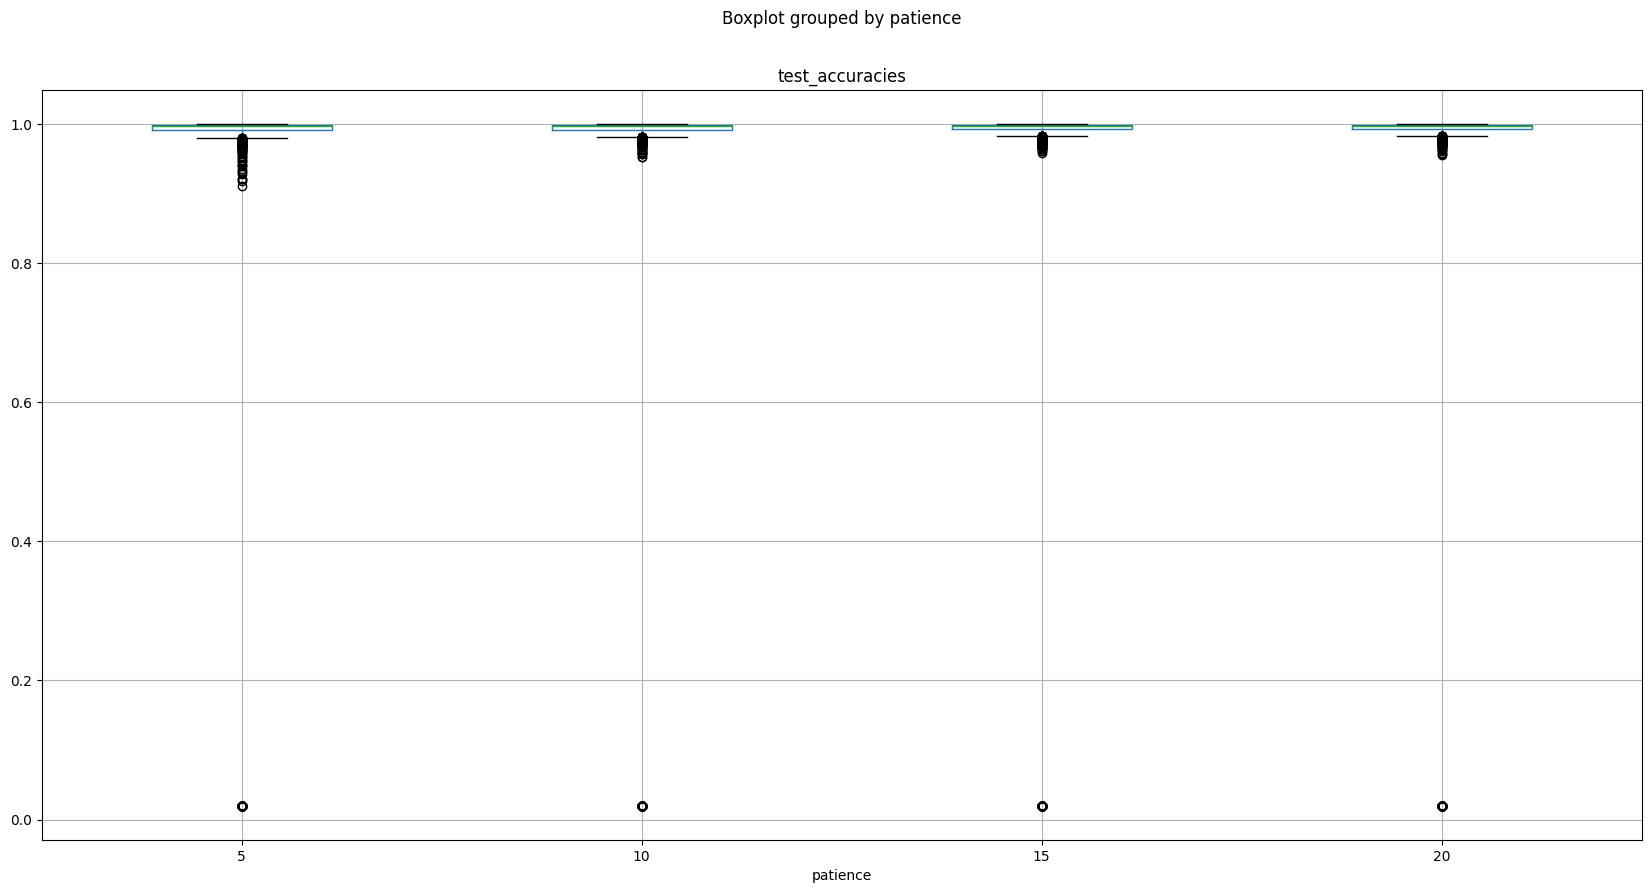

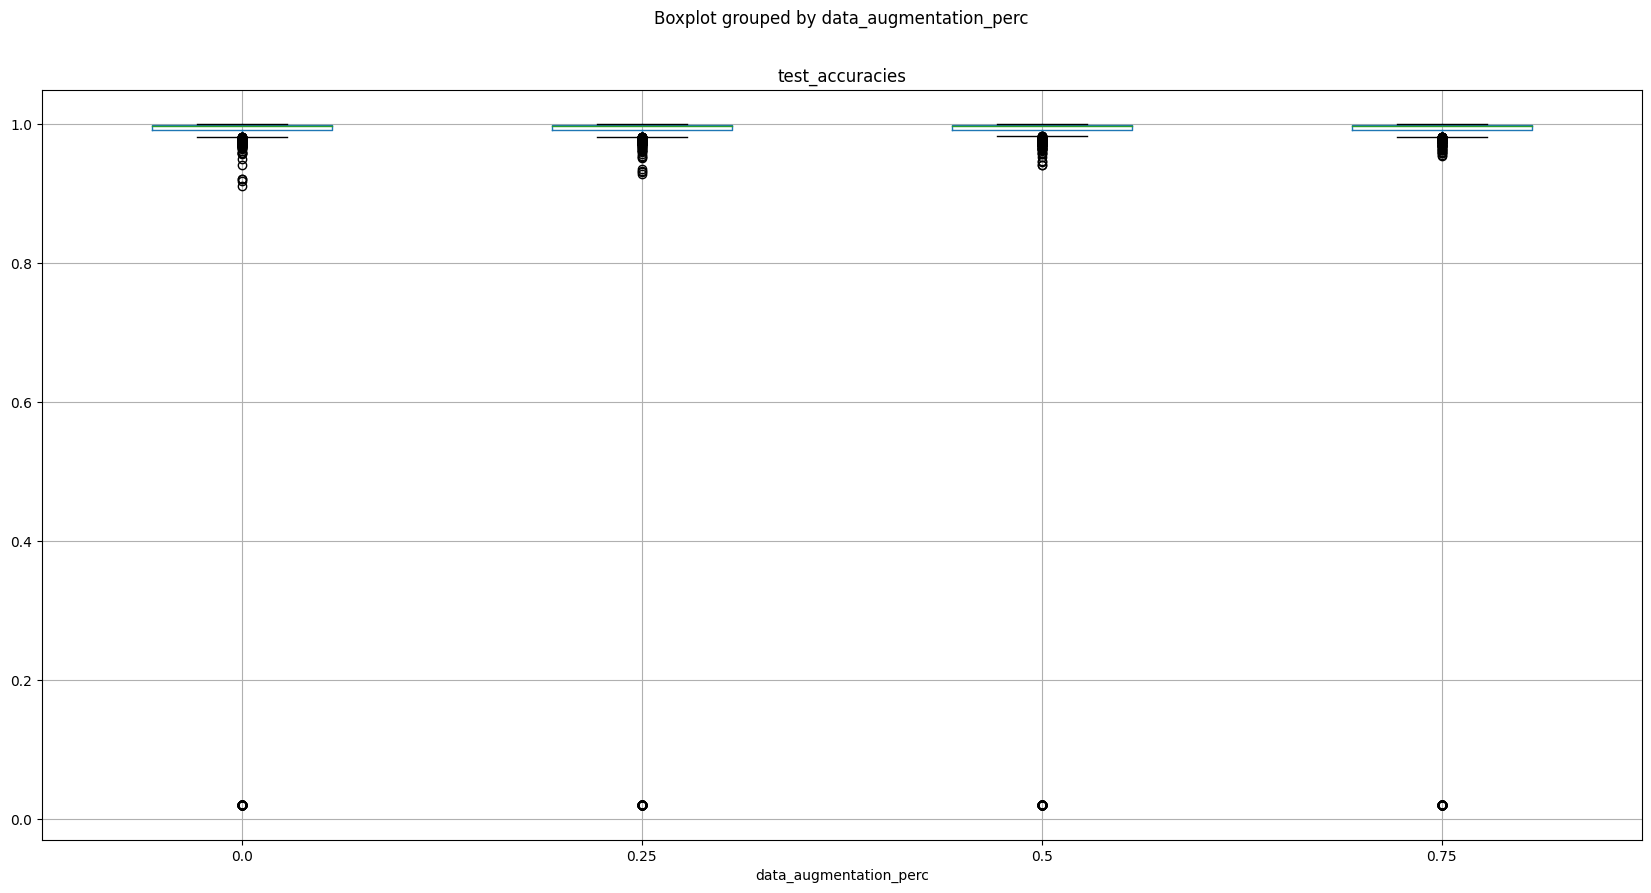

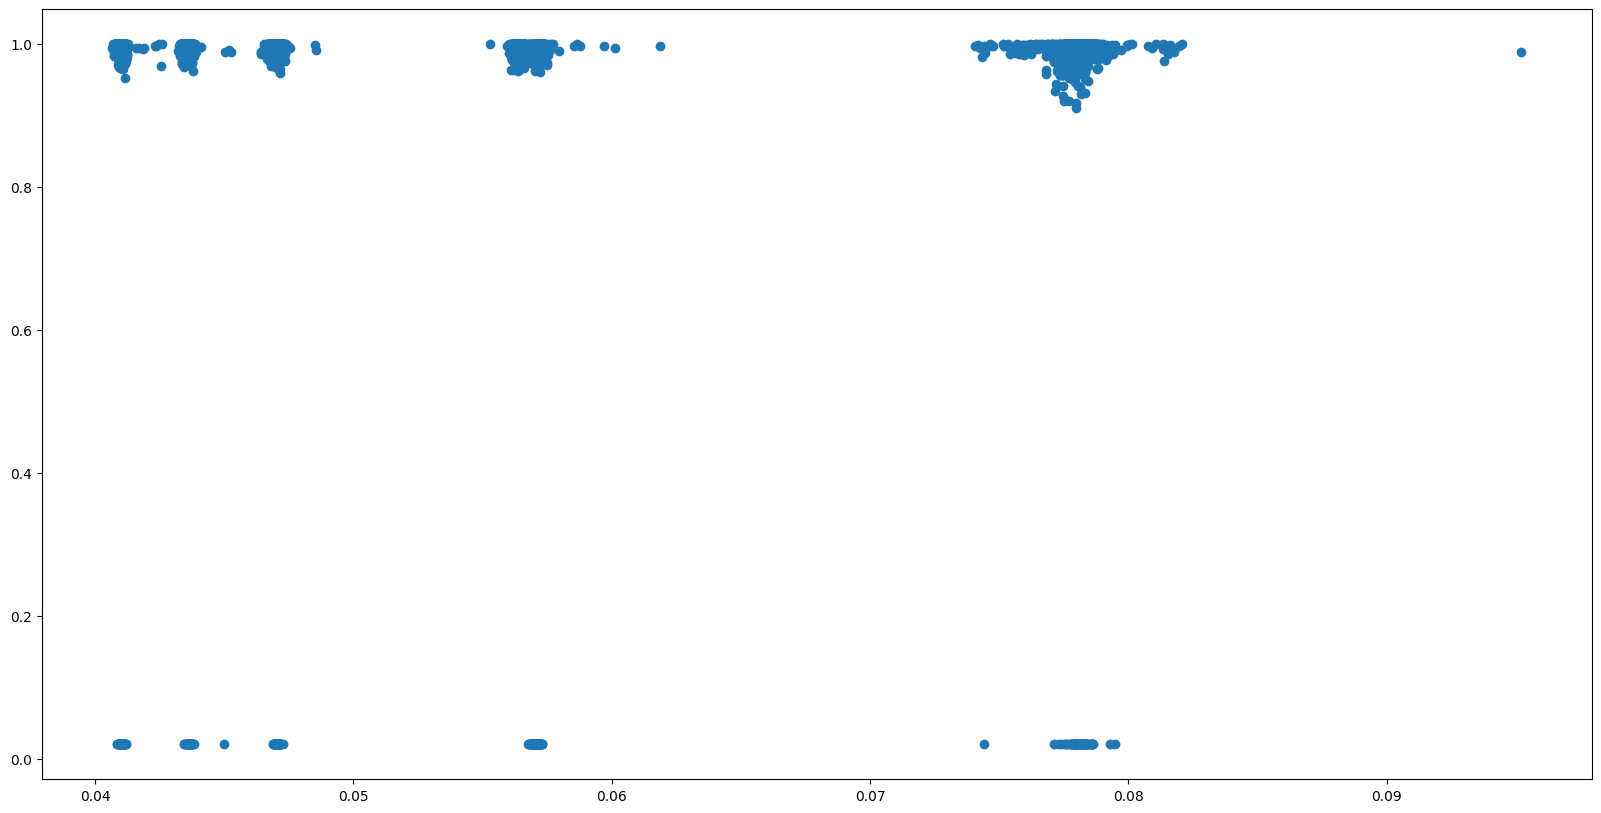

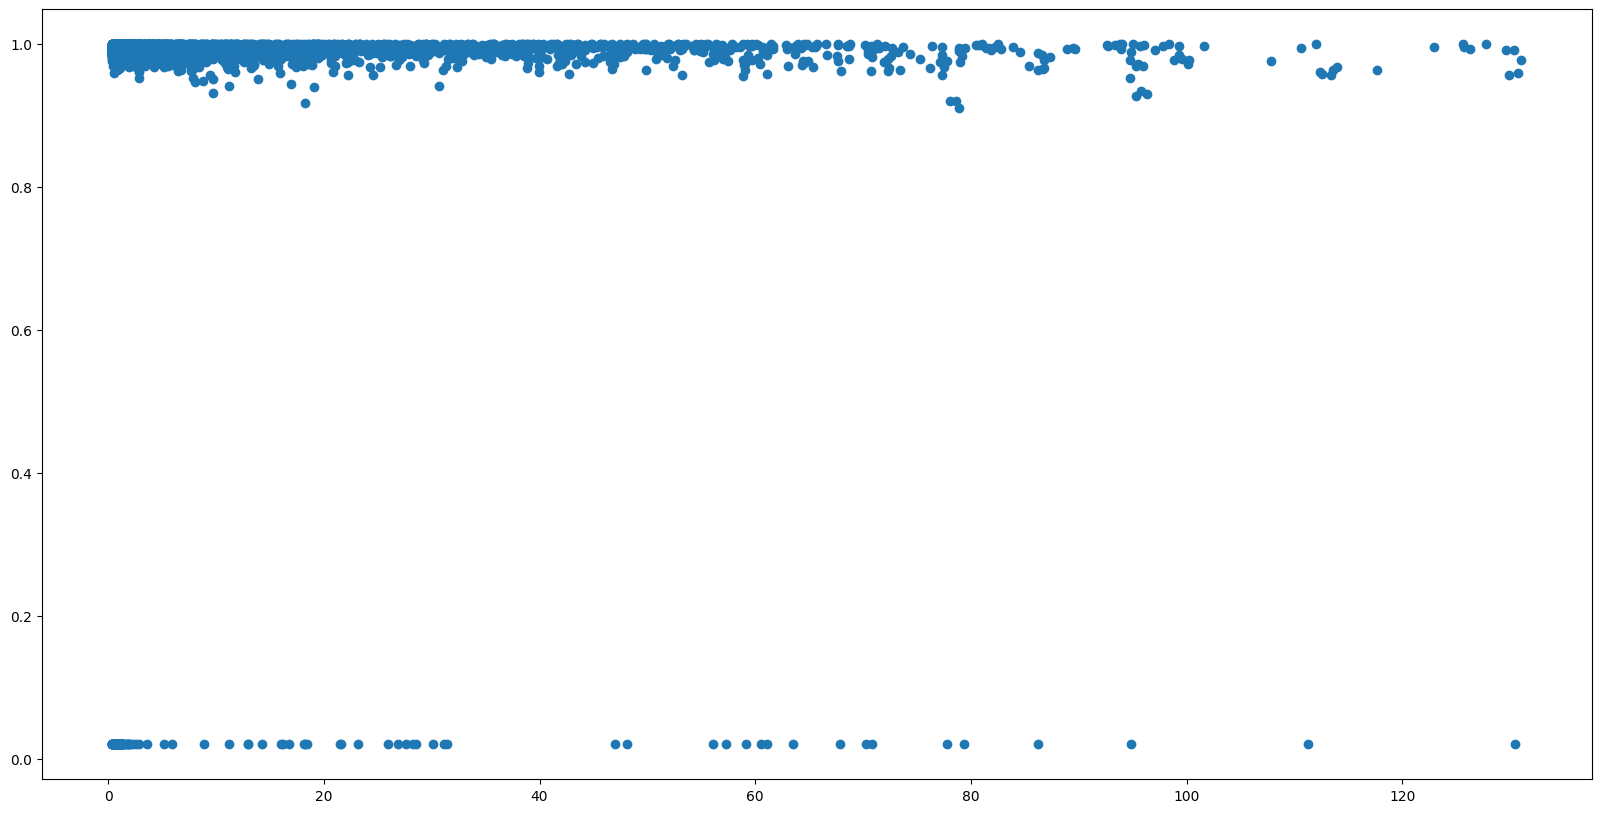

In [5]:
def plot_hyper():
    
    fig,ax=plt.subplots(figsize=(20,10))
    prova = all_results.sort_values(by="do_dropout")
    prova.boxplot(column =["test_accuracies"], by="do_dropout", ax=ax)
    
    fig,ax=plt.subplots(figsize=(20,10))
    all_results.boxplot(column =["test_accuracies"], by="n_neurons_molt_factor", ax=ax)
    
    fig,ax=plt.subplots(figsize=(20,10))
    all_results.boxplot(column =["test_accuracies"], by="lr", ax=ax)
    
    fig,ax=plt.subplots(figsize=(20,10))
    all_results.boxplot(column =["test_accuracies"], by="batch_size", ax=ax)
    
    fig,ax=plt.subplots(figsize=(20,10))
    all_results.boxplot(column =["test_accuracies"], by="patience", ax=ax)
    
    fig,ax=plt.subplots(figsize=(20,10))
    all_results.boxplot(column =["test_accuracies"], by="data_augmentation_perc", ax=ax)
    
    fig,ax=plt.subplots(figsize=(20,10))
    ax.scatter(all_results["test_times"], all_results["test_accuracies"])
    
    fig,ax=plt.subplots(figsize=(20,10))
    ax.scatter(all_results["train_times"], all_results["test_accuracies"])

plot_hyper()

In [6]:
all_results.sort_values(by=['test_accuracies'], ascending=False).head(10)

,test_id,architecture_id,n_neurons_molt_factor,do_dropout,lr,batch_size,patience,data_augmentation_perc,test_accuracies,test_times,train_times
7679,319,23,2.0,"['Conv2', 'FC1']",0.000001,512,20,0.75,1.0,0.041262,0.645797
6478,78,20,2.0,"['Conv2', 'Conv3']",0.000500,512,20,0.50,1.0,0.041176,46.007360
6475,75,20,2.0,"['Conv2', 'Conv3']",0.000500,512,15,0.75,1.0,0.042477,30.053959
6474,74,20,2.0,"['Conv2', 'Conv3']",0.000500,512,15,0.50,1.0,0.040992,54.516959
6473,73,20,2.0,"['Conv2', 'Conv3']",0.000500,512,15,0.25,1.0,0.041065,4.798297
6471,71,20,2.0,"['Conv2', 'Conv3']",0.000500,512,10,0.75,1.0,0.041117,25.479475
6469,69,20,2.0,"['Conv2', 'Conv3']",0.000500,512,10,0.25,1.0,0.041153,5.737983
6468,68,20,2.0,"['Conv2', 'Conv3']",0.000500,512,10,0.00,1.0,0.040940,0.764475
6467,67,20,2.0,"['Conv2', 'Conv3']",0.000500,512,5,0.75,1.0,0.041003,0.645216
6466,66,20,2.0,"['Conv2', 'Conv3']",0.000500,512,5,0.50,1.0,0.041087,0.557416


In [7]:
n_high_accuracy_architectures = len(all_results[all_results["test_accuracies"]==all_results["test_accuracies"].max()])
n_high_accuracy_architectures

688

In [8]:
high_accuracy_architectures = all_results.sort_values(by=['test_accuracies'], ascending=False).head(n_high_accuracy_architectures)["architecture_id"].unique()
high_accuracy_architectures

array([23, 20, 17, 18,  1,  4,  7,  2, 16, 15, 12, 10, 22, 21])

In [9]:
for model in high_accuracy_architectures:
    architecture_stats(all_results, classifiers_dict, model)

Stats for architecture: Classifier_3 (n_neurons_molt_factor=2, do_dropout=['Conv2', 'FC1']) (id: 23)
mean accuracy: 0.9993 with standard error: 0.0022

worst accuracy: 0.9810 with hyperparameters:
test_id                          5
lr                          0.0005
batch_size                      32
patience                        10
data_augmentation_perc        0.25
test_times                0.078145
train_times               1.880124
Name: 7365, dtype: object 

best accuracy: 1.0000 with hyperparameters:
test_id                         22
lr                          0.0005
batch_size                      64
patience                        10
data_augmentation_perc         0.5
test_times                0.057163
train_times               3.363832
Name: 7382, dtype: object 

Stats for architecture: Classifier_3 (n_neurons_molt_factor=2, do_dropout=['Conv2', 'Conv3']) (id: 20)
mean accuracy: 0.9991 with standard error: 0.0017

worst accuracy: 0.9862 with hyperparameters:
test_id       

Classifier_3 (n_neurons_molt_factor=2, do_dropout=['Conv2', 'FC1'])_test_319


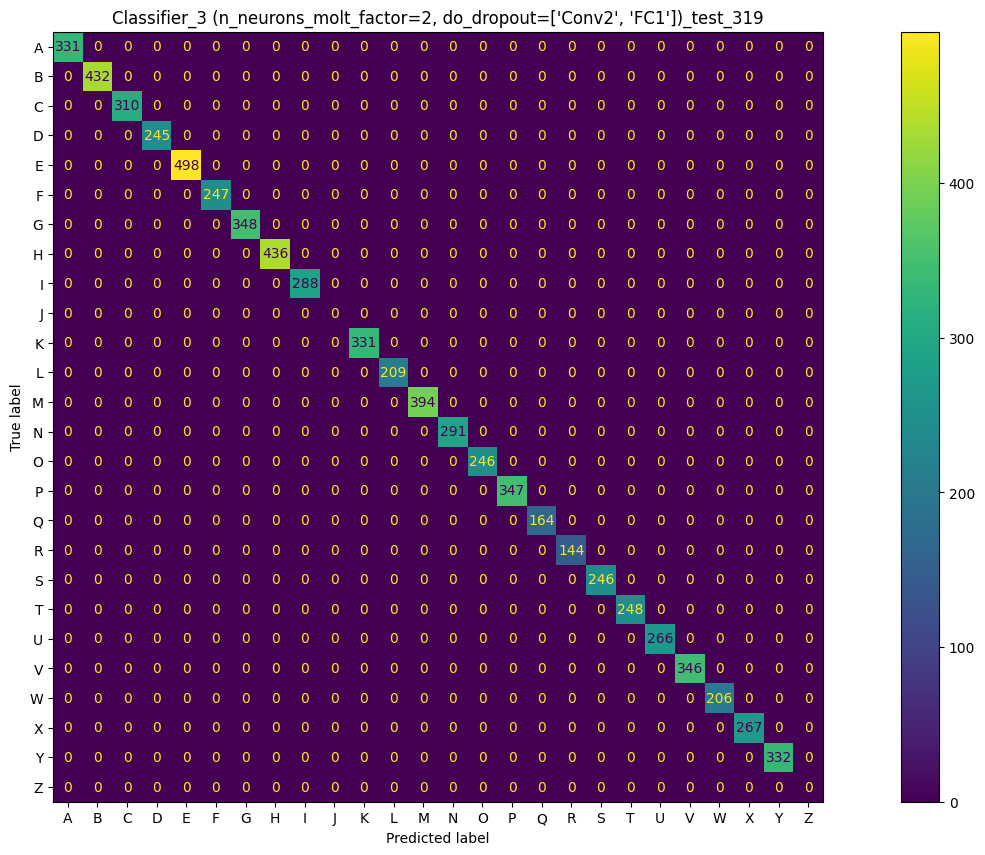

WRONG PREDICTIONS:


In [10]:
best_model = NeuralNetwork.load_NN(all_results.iloc[7679], classifiers_dict, torch.device("cuda"), (28,28))
best_model.explore_wrong_predictions()

In [11]:
all_results.sort_values(by=['test_accuracies'], ascending=True).head(10)

,test_id,architecture_id,n_neurons_molt_factor,do_dropout,lr,batch_size,patience,data_augmentation_perc,test_accuracies,test_times,train_times
0,0,0,2.0,['Conv2'],0.00050,32,5,0.00,0.020078,0.078545,79.387270
218,218,0,2.0,['Conv2'],0.00001,256,15,0.50,0.020078,0.043728,0.605537
217,217,0,2.0,['Conv2'],0.00001,256,15,0.25,0.020078,0.043590,0.510674
216,216,0,2.0,['Conv2'],0.00001,256,15,0.00,0.020078,0.043718,0.415790
215,215,0,2.0,['Conv2'],0.00001,256,10,0.75,0.020078,0.043665,70.803141
214,214,0,2.0,['Conv2'],0.00001,256,10,0.50,0.020078,0.043732,0.606151
213,213,0,2.0,['Conv2'],0.00001,256,10,0.25,0.020078,0.043670,0.508479
212,212,0,2.0,['Conv2'],0.00001,256,10,0.00,0.020078,0.043509,0.414539
219,219,0,2.0,['Conv2'],0.00001,256,15,0.75,0.020078,0.043611,0.735349
211,211,0,2.0,['Conv2'],0.00001,256,5,0.75,0.020078,0.043459,0.696963


In [12]:
n_low_accuracy_architectures = len(all_results[all_results["test_accuracies"]==all_results["test_accuracies"].min()])
n_low_accuracy_architectures

320

In [13]:
all_results.sort_values(by=['test_accuracies'], ascending=True).head(n_low_accuracy_architectures)["architecture_id"].unique()

array([0])

In [14]:
architecture_stats(all_results, classifiers_dict, 0)

Stats for architecture: Classifier_3 (n_neurons_molt_factor=2, do_dropout=['Conv2']) (id: 0)
mean accuracy: 0.0201 with standard error: 0.0000

worst accuracy: 0.0201 with hyperparameters:
test_id                          0
lr                          0.0005
batch_size                      32
patience                         5
data_augmentation_perc         0.0
test_times                0.078545
train_times               79.38727
Name: 0, dtype: object 

best accuracy: 0.0201 with hyperparameters:
test_id                          0
lr                          0.0005
batch_size                      32
patience                         5
data_augmentation_perc         0.0
test_times                0.078545
train_times               79.38727
Name: 0, dtype: object 



Classifier_3 (n_neurons_molt_factor=2, do_dropout=['Conv2'])_test_0


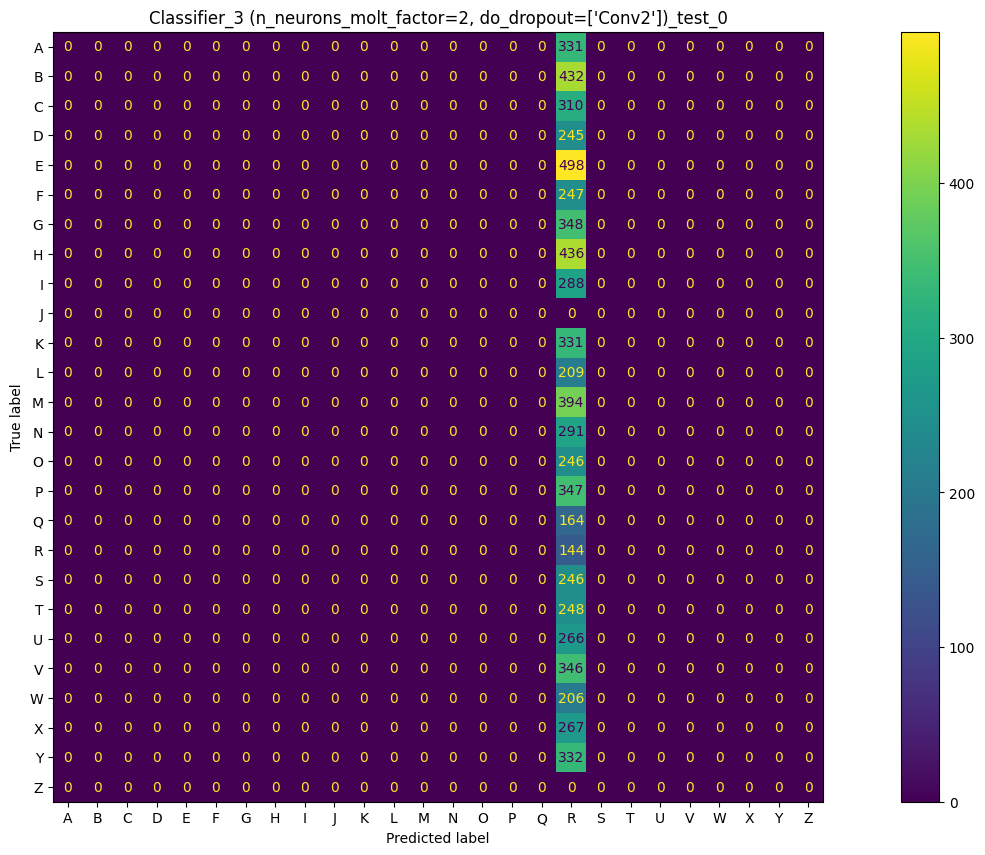

In [15]:
NeuralNetwork.load_NN(all_results.iloc[0], classifiers_dict, torch.device("cuda"), (28,28)).plot_confusion_matrix()

In [16]:
all_results.sort_values(by=['test_accuracies'], ascending=True).iloc[320:330]

,test_id,architecture_id,n_neurons_molt_factor,do_dropout,lr,batch_size,patience,data_augmentation_perc,test_accuracies,test_times,train_times
2880,0,9,2.0,[],0.0005,32,5,0.00,0.910904,0.077954,78.910970
4480,0,14,0.6,"['Conv3', 'FC1']",0.0005,32,5,0.00,0.917875,0.077965,18.235616
960,0,3,0.6,[],0.0005,32,5,0.00,0.920385,0.077508,78.074892
1600,0,5,1.0,[],0.0005,32,5,0.00,0.920943,0.077699,78.579071
961,1,3,0.6,[],0.0005,32,5,0.25,0.928193,0.077447,95.286937
2881,1,9,2.0,[],0.0005,32,5,0.25,0.930145,0.078176,96.361620
2561,1,8,2.0,['FC1'],0.0005,32,5,0.25,0.932376,0.078335,9.746702
1601,1,5,1.0,[],0.0005,32,5,0.25,0.935025,0.077141,95.793854
2560,0,8,2.0,['FC1'],0.0005,32,5,0.00,0.940045,0.078112,19.085825
2882,2,9,2.0,[],0.0005,32,5,0.50,0.941021,0.078050,30.691177


Classifier_3 (n_neurons_molt_factor=2, do_dropout=[])_test_0


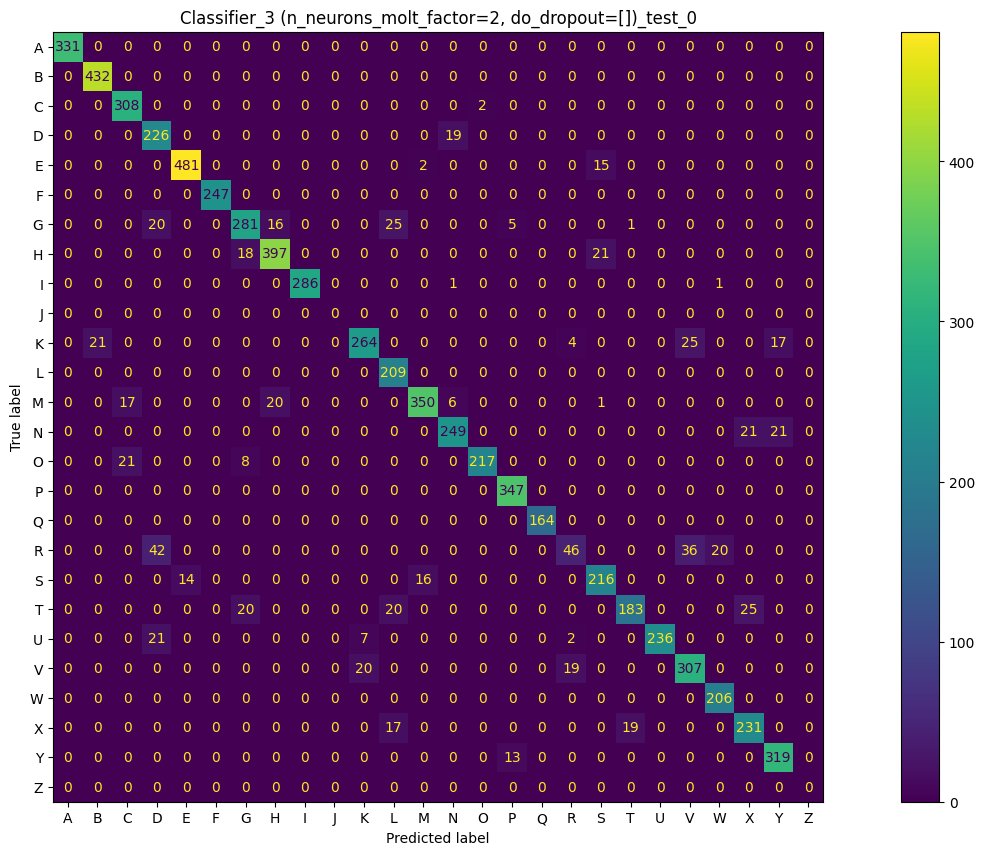

In [17]:
model = NeuralNetwork.load_NN(all_results.iloc[2880], classifiers_dict, torch.device("cuda"), (28,28))
model.plot_confusion_matrix()

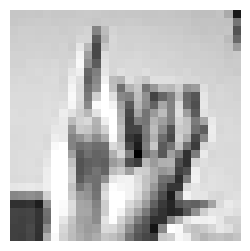

True label: I


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 1.0,
 'J': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.0,
 'Y': 0.0}

In [18]:
image, response = sample_image(index = 10)
best_model.predict(image)

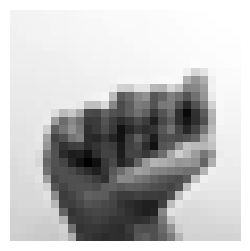

True response: A
Predicted response: C


{'A': 0.0393,
 'B': 0.0,
 'C': 0.9606,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'J': 0.0,
 'K': 0.0,
 'L': 1e-04,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.0,
 'Y': 0.0}

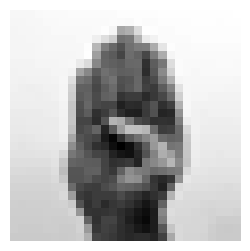

True response: B
Predicted response: E


{'A': 0.0982,
 'B': 0.0484,
 'C': 0.0022,
 'D': 0.0233,
 'E': 0.7215,
 'F': 0.0014,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0005,
 'J': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0385,
 'N': 0.0235,
 'O': 0.0087,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0338,
 'T': 0.0,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.0,
 'Y': 0.0}

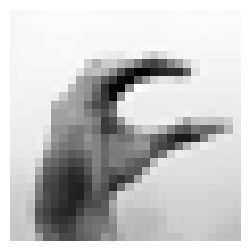

True response: C
Predicted response: C


{'A': 0.0,
 'B': 0.0,
 'C': 1.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'J': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.0,
 'Y': 0.0}

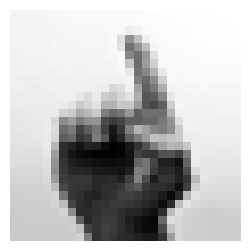

True response: D
Predicted response: L


{'A': 0.0,
 'B': 0.0,
 'C': 0.0007,
 'D': 0.439,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'J': 0.0,
 'K': 0.0,
 'L': 0.465,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0152,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.08,
 'Y': 0.0}

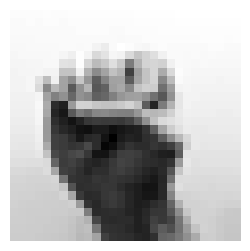

True response: E
Predicted response: U


{'A': 0.0395,
 'B': 0.0339,
 'C': 0.0162,
 'D': 0.048,
 'E': 0.0312,
 'F': 0.0336,
 'G': 0.0652,
 'H': 0.0552,
 'I': 0.0425,
 'J': 0.0004,
 'K': 0.0247,
 'L': 0.0483,
 'M': 0.0528,
 'N': 0.0415,
 'O': 0.0199,
 'P': 0.0409,
 'Q': 0.0219,
 'R': 0.0365,
 'S': 0.0362,
 'T': 0.0393,
 'U': 0.066,
 'V': 0.0632,
 'W': 0.0588,
 'X': 0.0496,
 'Y': 0.0349}

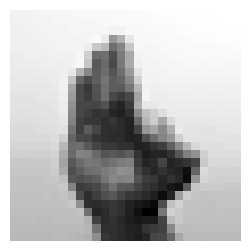

True response: F
Predicted response: F


{'A': 0.0233,
 'B': 0.0002,
 'C': 0.1958,
 'D': 0.0128,
 'E': 0.0133,
 'F': 0.3347,
 'G': 0.0669,
 'H': 0.0948,
 'I': 0.0007,
 'J': 0.0,
 'K': 0.0,
 'L': 0.0416,
 'M': 0.0,
 'N': 0.0,
 'O': 0.1803,
 'P': 0.0,
 'Q': 0.0024,
 'R': 0.0,
 'S': 0.0,
 'T': 0.024,
 'U': 0.0,
 'V': 0.0012,
 'W': 0.0009,
 'X': 0.0061,
 'Y': 0.0011}

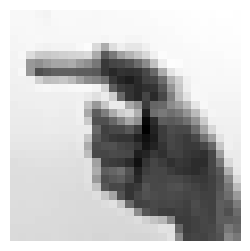

True response: G
Predicted response: P


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'J': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 1.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.0,
 'Y': 0.0}

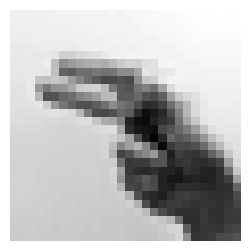

True response: H
Predicted response: P


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'J': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 1.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.0,
 'Y': 0.0}

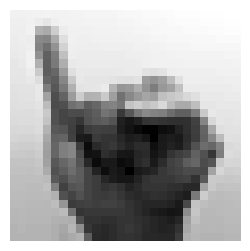

True response: I
Predicted response: H


{'A': 0.0,
 'B': 0.0,
 'C': 0.0002,
 'D': 0.0,
 'E': 0.0,
 'F': 1e-04,
 'G': 0.117,
 'H': 0.8794,
 'I': 0.0,
 'J': 0.0,
 'K': 0.0,
 'L': 1e-04,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0031,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.0,
 'Y': 0.0}

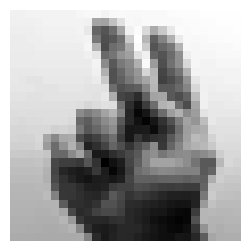

True response: K
Predicted response: X


{'A': 0.0,
 'B': 1e-04,
 'C': 0.0046,
 'D': 0.0645,
 'E': 0.0009,
 'F': 0.0,
 'G': 0.0799,
 'H': 0.0437,
 'I': 0.0012,
 'J': 0.0,
 'K': 1e-04,
 'L': 0.062,
 'M': 0.0228,
 'N': 0.0082,
 'O': 0.0079,
 'P': 0.0005,
 'Q': 0.0088,
 'R': 1e-04,
 'S': 0.0072,
 'T': 0.0591,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0003,
 'X': 0.6275,
 'Y': 0.0005}

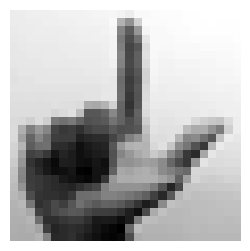

True response: L
Predicted response: L


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'J': 0.0,
 'K': 0.0,
 'L': 1.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.0,
 'Y': 0.0}

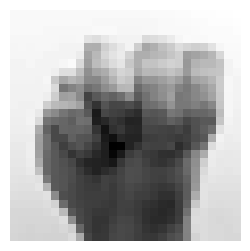

True response: M
Predicted response: C


{'A': 0.0282,
 'B': 0.0,
 'C': 0.3004,
 'D': 0.0166,
 'E': 0.0104,
 'F': 0.0611,
 'G': 0.1072,
 'H': 0.1143,
 'I': 0.0,
 'J': 0.0,
 'K': 0.0,
 'L': 0.0791,
 'M': 0.0338,
 'N': 0.0052,
 'O': 0.1728,
 'P': 0.0,
 'Q': 0.0033,
 'R': 0.0,
 'S': 0.0025,
 'T': 0.0323,
 'U': 0.0,
 'V': 0.002,
 'W': 0.0,
 'X': 0.0306,
 'Y': 1e-04}

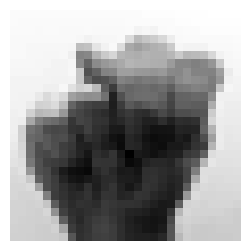

True response: N
Predicted response: M


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0038,
 'E': 0.0011,
 'F': 0.0,
 'G': 0.0,
 'H': 1e-04,
 'I': 0.0023,
 'J': 0.0,
 'K': 0.0,
 'L': 0.0026,
 'M': 0.6283,
 'N': 0.0184,
 'O': 0.0,
 'P': 0.0028,
 'Q': 0.0325,
 'R': 0.0,
 'S': 0.0073,
 'T': 0.0,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.3009,
 'Y': 0.0}

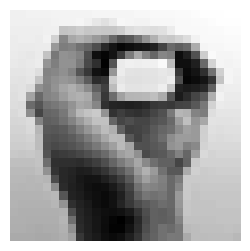

True response: O
Predicted response: T


{'A': 0.0,
 'B': 1e-04,
 'C': 1e-04,
 'D': 0.0105,
 'E': 0.0,
 'F': 0.0015,
 'G': 0.1277,
 'H': 0.109,
 'I': 0.0003,
 'J': 0.0,
 'K': 0.0014,
 'L': 0.005,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0014,
 'Q': 0.0,
 'R': 0.0072,
 'S': 0.0,
 'T': 0.7023,
 'U': 0.0015,
 'V': 0.0078,
 'W': 0.0023,
 'X': 0.0212,
 'Y': 0.0008}

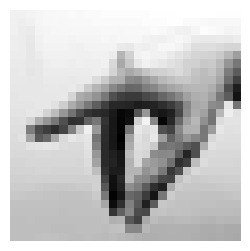

True response: P
Predicted response: O


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'J': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 1.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.0,
 'Y': 0.0}

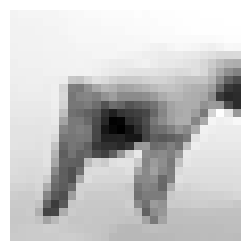

True response: Q
Predicted response: H


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0045,
 'H': 0.9954,
 'I': 0.0,
 'J': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 1e-04,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.0,
 'Y': 0.0}

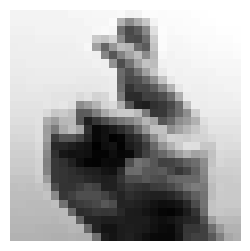

True response: R
Predicted response: P


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0019,
 'I': 0.0,
 'J': 0.0,
 'K': 1e-04,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0007,
 'P': 0.9925,
 'Q': 0.004,
 'R': 1e-04,
 'S': 0.0003,
 'T': 0.0002,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.0002,
 'Y': 0.0}

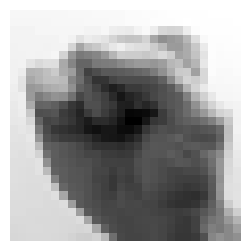

True response: S
Predicted response: H


{'A': 0.0,
 'B': 0.0,
 'C': 0.0004,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0006,
 'G': 0.2382,
 'H': 0.618,
 'I': 0.0013,
 'J': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0191,
 'Q': 0.0495,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0634,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.0088,
 'Y': 0.0006}

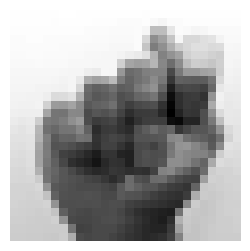

True response: T
Predicted response: U


{'A': 0.0395,
 'B': 0.0339,
 'C': 0.0162,
 'D': 0.048,
 'E': 0.0312,
 'F': 0.0336,
 'G': 0.0652,
 'H': 0.0552,
 'I': 0.0425,
 'J': 0.0004,
 'K': 0.0247,
 'L': 0.0483,
 'M': 0.0528,
 'N': 0.0415,
 'O': 0.0199,
 'P': 0.0409,
 'Q': 0.0219,
 'R': 0.0365,
 'S': 0.0362,
 'T': 0.0393,
 'U': 0.066,
 'V': 0.0632,
 'W': 0.0588,
 'X': 0.0496,
 'Y': 0.0349}

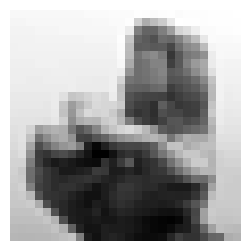

True response: U
Predicted response: U


{'A': 0.0395,
 'B': 0.0339,
 'C': 0.0162,
 'D': 0.048,
 'E': 0.0312,
 'F': 0.0336,
 'G': 0.0652,
 'H': 0.0552,
 'I': 0.0425,
 'J': 0.0004,
 'K': 0.0247,
 'L': 0.0483,
 'M': 0.0528,
 'N': 0.0415,
 'O': 0.0199,
 'P': 0.0409,
 'Q': 0.0219,
 'R': 0.0365,
 'S': 0.0362,
 'T': 0.0393,
 'U': 0.066,
 'V': 0.0632,
 'W': 0.0588,
 'X': 0.0496,
 'Y': 0.0349}

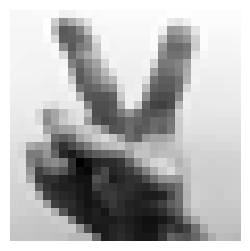

True response: V
Predicted response: Y


{'A': 0.0171,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0153,
 'E': 0.0,
 'F': 0.0155,
 'G': 0.0223,
 'H': 0.0554,
 'I': 0.1368,
 'J': 0.0,
 'K': 0.023,
 'L': 0.1441,
 'M': 0.0,
 'N': 0.0065,
 'O': 0.0,
 'P': 0.0244,
 'Q': 0.0014,
 'R': 0.0553,
 'S': 0.0099,
 'T': 0.0512,
 'U': 0.0061,
 'V': 0.0842,
 'W': 0.0139,
 'X': 0.0122,
 'Y': 0.3054}

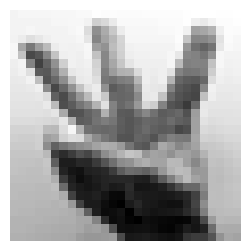

True response: W
Predicted response: Y


{'A': 0.0002,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0037,
 'J': 0.0,
 'K': 0.0,
 'L': 0.0008,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 1e-04,
 'S': 0.0,
 'T': 0.0,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.0,
 'Y': 0.9953}

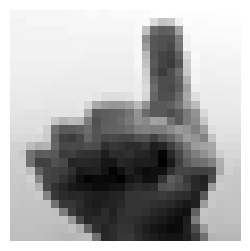

True response: X
Predicted response: H


{'A': 0.0046,
 'B': 0.0,
 'C': 0.0223,
 'D': 0.0024,
 'E': 0.0,
 'F': 0.019,
 'G': 0.3235,
 'H': 0.4382,
 'I': 0.0004,
 'J': 0.0,
 'K': 0.0,
 'L': 0.0412,
 'M': 0.0031,
 'N': 0.0057,
 'O': 0.0003,
 'P': 1e-04,
 'Q': 0.0065,
 'R': 0.0,
 'S': 0.0013,
 'T': 0.0848,
 'U': 0.0,
 'V': 0.0002,
 'W': 0.0,
 'X': 0.0449,
 'Y': 0.0015}

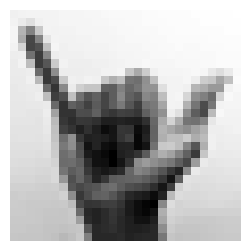

True response: Y
Predicted response: Y


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'J': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.0,
 'Y': 1.0}

0.20833333333333334


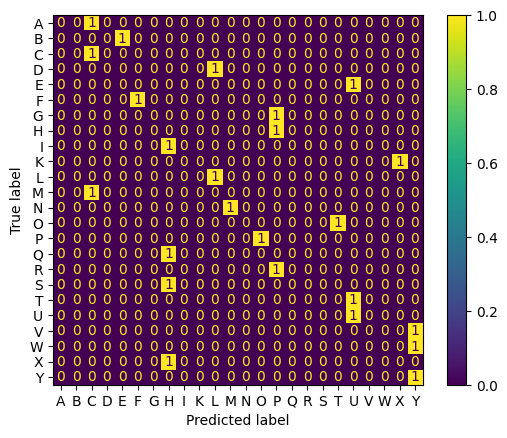

In [19]:
best_model.custom_images_test()